In [1]:
# NAME: OMONIYI INIOLUWA GABRIEL
# DEPARTMENT: MECHATRONICS ENGINEERING
# MATRIC NO.: F/ND/24/3450057
# STUDENT ID.: STU005    
# !pip install pandas matplotlib openpyxl
# print('all libriry installed')

In [2]:
# Cell 1 — Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
# This formatter will make y-axis show real numbers like $25,000,000
# instead of scientific notation like 2.5e7
money_fmt = mticker.FuncFormatter(lambda x, _: f"${x:,.0f}")
print('Ready!')

Ready!


In [3]:
# Cell 2 — Load the dataset
df = pd.read_excel('dataset/finance_transactions_dataset.xlsx')
# Quick check: how many rows and columns?
print(df.shape)        # e.g. (1000, 14)
print(df.columns.tolist())

(1000, 14)
['Transaction_ID', 'Company', 'Sector', 'Department', 'Transaction_Type', 'Category', 'Amount', 'Tax_Rate', 'Tax_Amount', 'Net_Amount', 'Currency', 'Transaction_Date', 'Approval_Status', 'Analyst']


In [5]:
# Cell 3a
df.head()
# Cell 3b
df.info()
# Cell 3c
df.describe().round(2)
# Cell 3d
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction_ID    1000 non-null   object 
 1   Company           956 non-null    object 
 2   Sector            1000 non-null   object 
 3   Department        946 non-null    object 
 4   Transaction_Type  1000 non-null   object 
 5   Category          211 non-null    object 
 6   Amount            961 non-null    float64
 7   Tax_Rate          1000 non-null   float64
 8   Tax_Amount        1000 non-null   float64
 9   Net_Amount        960 non-null    float64
 10  Currency          1000 non-null   object 
 11  Transaction_Date  952 non-null    object 
 12  Approval_Status   961 non-null    object 
 13  Analyst           955 non-null    object 
dtypes: float64(4), object(10)
memory usage: 109.5+ KB


Transaction_ID        0
Company              44
Sector                0
Department           54
Transaction_Type      0
Category            789
Amount               39
Tax_Rate              0
Tax_Amount            0
Net_Amount           40
Currency              0
Transaction_Date     48
Approval_Status      39
Analyst              45
dtype: int64

In [6]:
# Cell 4a — Remove rows where essential columns are empty
df.dropna(subset=['Amount', 'Net_Amount', 'Transaction_Date', 
'Approval_Status'],
          inplace=True)
print('Rows remaining:', len(df))

Rows remaining: 845


In [7]:
# Cell 4b — Fill gaps in text columns
df['Company']    = df['Company'].fillna('Unknown')
df['Department'] = df['Department'].fillna('Unknown')
df['Analyst']    = df['Analyst'].fillna('Unknown')
df['Category']   = df['Category'].fillna('N/A')
# Cell 4c — Turn text dates into proper dates, then extract Year and Month
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'], 
errors='coerce')
df.dropna(subset=['Transaction_Date'], inplace=True)
df['Year']  = df['Transaction_Date'].dt.year
df['Month'] = df['Transaction_Date'].dt.to_period('M').astype(str)
print('Sample dates:')
print(df[['Transaction_Date', 'Year', 'Month']].head(5))
# Cell 4d
df.drop_duplicates(inplace=True)
print('Final row count:', len(df))

Sample dates:
  Transaction_Date  Year    Month
0       2022-05-24  2022  2022-05
1       2023-08-04  2023  2023-08
2       2023-08-05  2023  2023-08
3       2024-11-01  2024  2024-11
4       2021-09-16  2021  2021-09
Final row count: 845


In [6]:
df.shape

(845, 16)

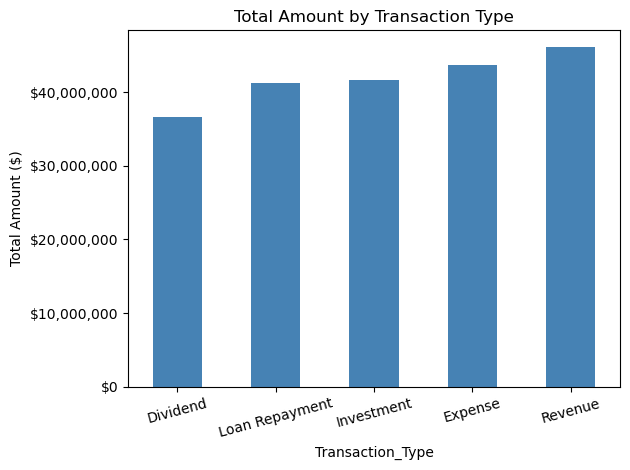

In [8]:
# DATA VISUALIZATION
# Cell 5a — Bar chart
df.groupby('Transaction_Type')['Amount'].sum().sort_values().plot(kind='bar', 
color='steelblue')
plt.title('Total Amount by Transaction Type')
plt.ylabel('Total Amount ($)')
plt.xticks(rotation=15)
plt.gca().yaxis.set_major_formatter(money_fmt)   # show real numbers, not 
2.5e7
plt.tight_layout()
plt.show()

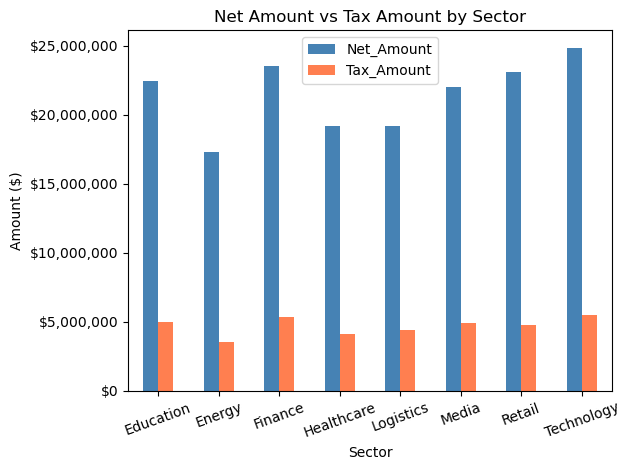

In [9]:
# Cell 5b — Grouped bar chart
df.groupby('Sector')[['Net_Amount', 'Tax_Amount']].sum().plot(kind='bar', 
color=['steelblue', 'coral'])
plt.title('Net Amount vs Tax Amount by Sector')
plt.ylabel('Amount ($)')
plt.xticks(rotation=20)
plt.gca().yaxis.set_major_formatter(money_fmt)   # show real numbers, not 2.5e7
plt.tight_layout()
plt.show()

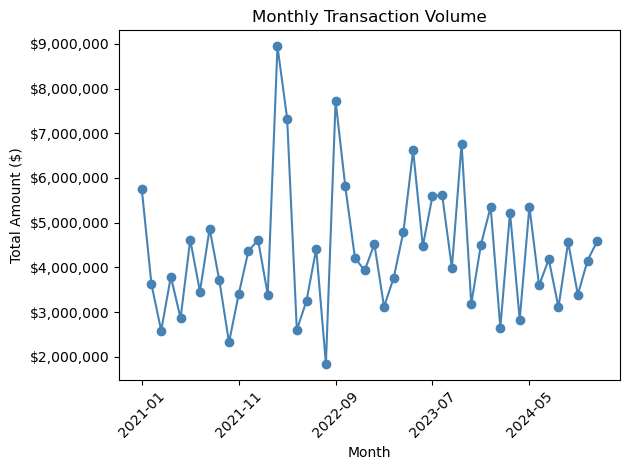

In [10]:
df.groupby('Month')['Amount'].sum().plot(kind='line', marker='o', 
color='steelblue')
plt.title('Monthly Transaction Volume')
plt.ylabel('Total Amount ($)')
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(money_fmt)   # show real numbers, not 2.5e7
plt.tight_layout()
plt.show()

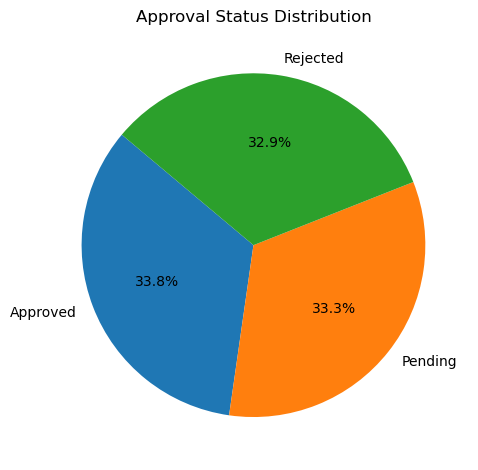

In [11]:
# Cell 5d — Pie chart
df['Approval_Status'].value_counts().plot(kind='pie', autopct='%1.1f%%', 
startangle=140)
plt.title('Approval Status Distribution')
plt.ylabel('')   # hides the default y-axis label on pie charts
plt.tight_layout()
plt.show()

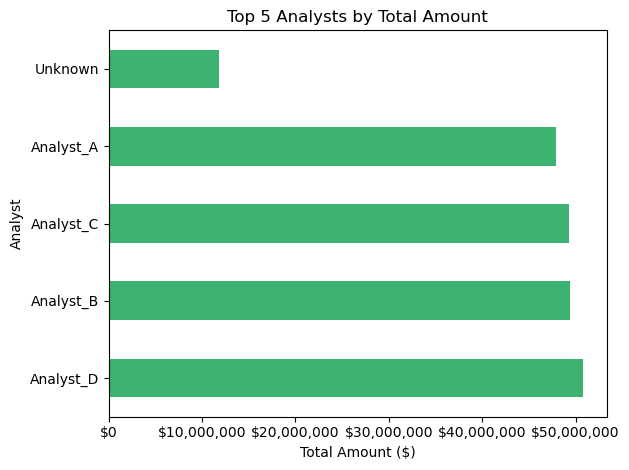

In [14]:
# Cell 5e — Horizontal bar chart
df.groupby('Analyst')['Amount'].sum().nlargest(5).plot(kind='barh', 
color='mediumseagreen')
plt.title('Top 5 Analysts by Total Amount')
plt.xlabel('Total Amount ($)')
plt.gca().xaxis.set_major_formatter(money_fmt)   # x-axis for horizontal bars
plt.tight_layout()
plt.show()

In [13]:
# Cell 6 — Summary
print('=' * 46)
print('           FINANCE DATASET SUMMARY')
print('=' * 46)
print(f"Transactions:       {len(df):,}")
print(f"Total Amount:       ${df['Amount'].sum():,.0f}")
print(f"Total Tax Paid:     ${df['Tax_Amount'].sum():,.0f}")
print(f"Total Net Amount:   ${df['Net_Amount'].sum():,.0f}")
print(f"Avg Tax Rate:       {df['Tax_Rate'].mean()*100:.1f}%")
print(f"Approval Rate:      {(df['Approval_Status']=='Approved').mean()*100:.1f}%")
print(f"Top Sector:         {df.groupby('Sector')['Amount'].sum().idxmax()}")
print(f"Top Analyst:        {df.groupby('Analyst')
['Amount'].sum().idxmax()}")
print('=' * 46)

           FINANCE DATASET SUMMARY
Transactions:       845
Total Amount:       $209,284,457
Total Tax Paid:     $37,622,745
Total Net Amount:   $171,661,713
Avg Tax Rate:       17.9%
Approval Rate:      33.8%
Top Sector:         Technology
Top Analyst:        Analyst_D


In [ ]:
# challenge exercises

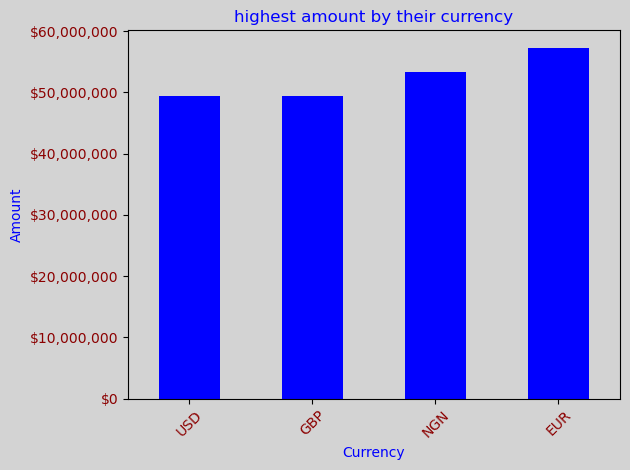

In [14]:
# 1 Bar chart: Which currency has the highest total Amount? Group by Currency, sum Amount, and plot. Use kind='bar'.
plt.figure(facecolor='lightgrey')
df.groupby('Currency')['Amount'].sum().sort_values().plot(kind='bar',
color='blue')
plt.title('highest amount by their currency', color='blue')
plt.ylabel('Amount', color='blue')
plt.xlabel('Currency', color='blue')
plt.xticks(color='darkred', rotation=45)
plt.yticks(color='darkred')
ax = plt.gca()
ax.set_facecolor('lightgray')
plt.gca().yaxis.set_major_formatter(money_fmt)

plt.tight_layout()
plt.show()

In [17]:
# 2 Line chart: Plot monthly Net_Amount for Approved transactions only. First filter: 
# approved = df[df['Approval_Status'] == 'Approved'], then group by Month and plot.
approved = df[df['Approval_Status'] == 'Approved']

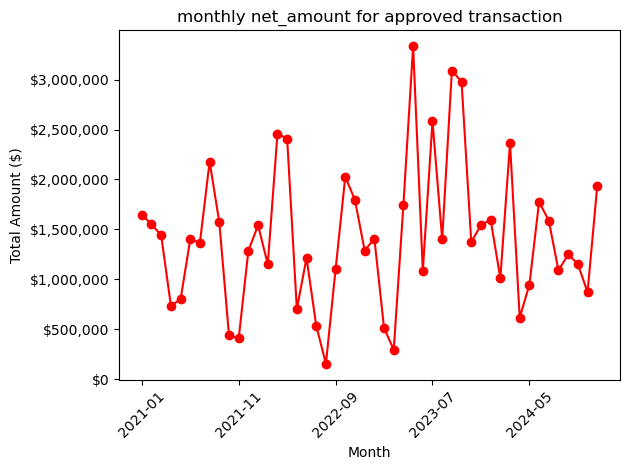

In [18]:
approved = df[df['Approval_Status'] == 'Approved']
approved.groupby('Month')['Amount'].sum().plot(kind='line', marker='o', 
color='red')
plt.title('monthly net_amount for approved transaction')
plt.ylabel('Total Amount ($)')
plt.xticks(rotation=45)

plt.gca().yaxis.set_major_formatter(money_fmt)   # show real numbers, not 2.5e7
plt.tight_layout()
plt.show()

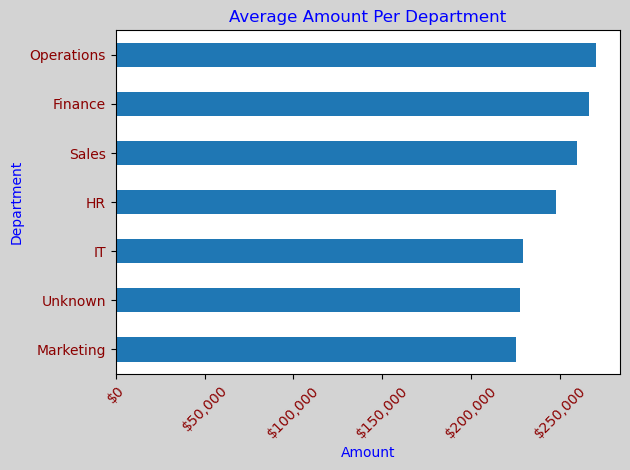

In [15]:
#3. Show average Amount per Department
plt.figure(facecolor='lightgrey')
df.groupby('Department')['Amount'].mean().sort_values().plot(kind='barh')
plt.title('Average Amount Per Department', color='blue')
plt.ylabel('Department', color='blue')
plt.xlabel('Amount', color='blue')
plt.xticks(color='darkred', rotation=45)
plt.yticks(color='darkred')
ax = plt.gca()
ax.set_facecolor('white')
plt.gca().xaxis.set_major_formatter(money_fmt)

plt.tight_layout()
plt.show()

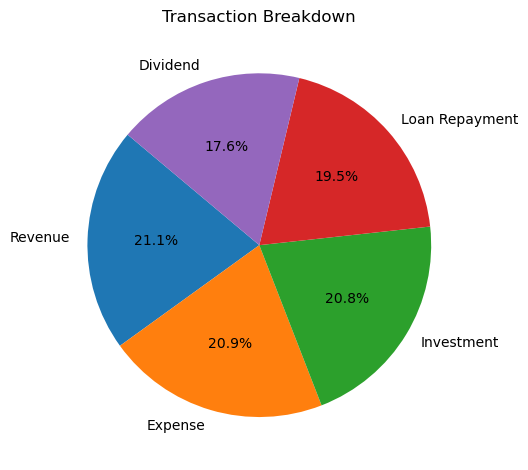

In [32]:
#4 Pie chart: Showing the breakdown of transactions
df['Transaction_Type'].value_counts().plot(kind='pie', autopct='%1.1f%%', 
startangle=140)
plt.title('Transaction Breakdown')
plt.ylabel('')   # hides the default y-axis label on pie charts
plt.tight_layout()
plt.show()

In [50]:
# 5 Bar chart: For Expense rows only, show the total Amount by Category
expense = df[df['Transaction_Type'] == 'Expense']
print('ready')


ready


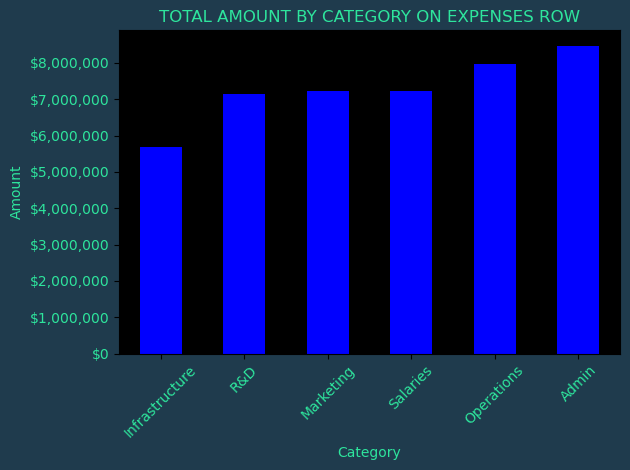

In [73]:
plt.figure(facecolor='#1f3b4d')
expense.groupby('Category')['Amount'].sum().sort_values().plot(kind='bar',
color='blue')
plt.title('TOTAL AMOUNT BY CATEGORY ON EXPENSES ROW', color='#2ee59d')
plt.ylabel('Amount', color='#2ee59d')
plt.xlabel('Category', color='#2ee59d')
plt.xticks(color='#2ee59d', rotation=45)
plt.yticks(color='#2ee59d')
ax = plt.gca()
ax.set_facecolor('black')
plt.gca().yaxis.set_major_formatter(money_fmt)

plt.tight_layout()
plt.show()